In [14]:
import subprocess
packages = [
    "pandas", "numpy", "scikit-learn",
    "matplotlib", "seaborn", "nltk",
    "spacy", "beautifulsoup4", "joblib",
    "flask", "flask-cors", "imbalanced-learn",
    "PyMuPDF", "python-docx"
]
for pkg in packages:
    subprocess.run(["pip", "install", pkg])
print("All installed!")

All installed!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity
import joblib

print("All libraries imported!")

All libraries imported!


In [17]:
df = pd.read_csv('../data/raw/Resume.csv', encoding='utf-8')

print("=" * 50)
print("DATASET LOADED!")
print("=" * 50)
print(f"Total Resumes  : {len(df)}")
print(f"Columns        : {df.columns.tolist()}")
print(f"Categories     : {df['Category'].nunique()}")
print()
print(df['Category'].value_counts())

DATASET LOADED!
Total Resumes  : 3446
Columns        : ['ID', 'Resume_str', 'Resume_html', 'Category', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Un

In [18]:
print("DATASET INFORMATION")
print("=" * 50)
print()

print(f"Shape: {df.shape}")
print()

print("Data Types:")
print(df.dtypes)
print()

print("Missing Values:")
print(df.isnull().sum())
print()

print(f"Duplicate rows: {df.duplicated().sum()}")
print()

print("CATEGORY DISTRIBUTION:")
print("=" * 40)
cat_counts = df['Category'].value_counts()
print(cat_counts.to_string())
print()
print(f"Total unique categories: {df['Category'].nunique()}")

DATASET INFORMATION

Shape: (3446, 169)

Data Types:
ID              object
Resume_str      object
Resume_html     object
Category        object
Unnamed: 4      object
                 ...  
Unnamed: 164    object
Unnamed: 165    object
Unnamed: 166    object
Unnamed: 167    object
Unnamed: 168    object
Length: 169, dtype: object

Missing Values:
ID               115
Resume_str       732
Resume_html      825
Category         911
Unnamed: 4      3385
                ... 
Unnamed: 164    3444
Unnamed: 165    3445
Unnamed: 166    3445
Unnamed: 167    3445
Unnamed: 168    3445
Length: 169, dtype: int64

Duplicate rows: 736

CATEGORY DISTRIBUTION:
Category
INFORMATION-TECHNOLOGY                                                                                                                                                                                                                                                                                                                             

In [19]:
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('../data/raw/Resume.csv',
                     encoding='utf-8')

print("BEFORE CLEANING")
print("=" * 50)
print(f"Shape          : {df_raw.shape}")
print(f"Total rows     : {len(df_raw)}")
print(f"Total columns  : {len(df_raw.columns)}")
print()
print("First 4 columns:")
print(df_raw[['ID','Resume_str',
              'Resume_html','Category']].head(3))

BEFORE CLEANING
Shape          : (3446, 169)
Total rows     : 3446
Total columns  : 169

First 4 columns:
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  


In [20]:

df = df_raw[['ID', 'Resume_str',
             'Resume_html', 'Category']].copy()

print("KEPT ONLY 4 USEFUL COLUMNS")
print("=" * 50)
print(f"Shape now: {df.shape}")
print()
print("Nulls per column:")
print(df.isnull().sum())

KEPT ONLY 4 USEFUL COLUMNS
Shape now: (3446, 4)

Nulls per column:
ID             115
Resume_str     732
Resume_html    825
Category       911
dtype: int64


In [21]:
print("BEFORE:", len(df), "rows")

# Step 1: Drop duplicate rows
df = df.drop_duplicates()
print(f"After removing duplicates : {len(df)}")

# Step 2: Drop rows where Category is null
df = df.dropna(subset=['Category'])
print(f"After removing null Category: {len(df)}")

# Step 3: Drop rows where Resume_str is null
df = df.dropna(subset=['Resume_str'])
print(f"After removing null Resume  : {len(df)}")

# Step 4: Reset index
df.reset_index(drop=True, inplace=True)
print()
print("AFTER:", len(df), "rows")

BEFORE: 3446 rows
After removing duplicates : 2710
After removing null Category: 2521
After removing null Resume  : 2521

AFTER: 2521 rows


In [22]:
# These are the ONLY valid categories
VALID_CATEGORIES = [
    'INFORMATION-TECHNOLOGY', 'BUSINESS-DEVELOPMENT',
    'ADVOCATE',   'CHEF',          'FINANCE',
    'ENGINEERING','ACCOUNTANT',    'FITNESS',
    'AVIATION',   'SALES',         'HEALTHCARE',
    'CONSULTANT',  'BANKING',      'CONSTRUCTION',
    'PUBLIC-RELATIONS', 'HR',      'DESIGNER',
    'ARTS',       'TEACHER',       'APPAREL',
    'DIGITAL-MEDIA','AGRICULTURE', 'AUTOMOBILE', 'BPO'
]

print("BEFORE category fix:")
print(f"Unique categories: {df['Category'].nunique()}")
print()

# Clean category values
df['Category'] = df['Category'].astype(str).str.strip()
df['Category'] = df['Category'].str.upper()

# Keep ONLY rows with valid categories
df = df[df['Category'].isin(VALID_CATEGORIES)]
df.reset_index(drop=True, inplace=True)

print("AFTER category fix:")
print(f"Unique categories: {df['Category'].nunique()}")
print(f"Total rows left  : {len(df)}")
print()
print(df['Category'].value_counts().to_string())

BEFORE category fix:
Unique categories: 75

AFTER category fix:
Unique categories: 24
Total rows left  : 2458

Category
INFORMATION-TECHNOLOGY    119
BUSINESS-DEVELOPMENT      119
AVIATION                  117
CHEF                      117
FITNESS                   117
ACCOUNTANT                116
ENGINEERING               116
FINANCE                   116
BANKING                   115
ADVOCATE                  115
SALES                     115
CONSULTANT                115
HEALTHCARE                113
PUBLIC-RELATIONS          110
HR                        109
CONSTRUCTION              108
DESIGNER                  106
ARTS                      103
TEACHER                   102
APPAREL                    96
DIGITAL-MEDIA              95
AGRICULTURE                63
AUTOMOBILE                 35
BPO                        21


In [23]:
from bs4 import BeautifulSoup

def remove_html(text):
    """Remove all HTML tags from text."""
    text = str(text)
    # Method 1: BeautifulSoup
    try:
        text = BeautifulSoup(text,
                             'html.parser').get_text(
                             separator=' ')
    except:
        pass
    # Method 2: Regex backup
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_text(text):
    """Full text cleaning pipeline."""
    # Step 1: Remove HTML
    text = remove_html(text)
    # Step 2: Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Step 3: Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Step 4: Lowercase
    text = text.lower()
    # Step 5: Remove very short words
    words = [w for w in text.split() if len(w) > 2]
    return ' '.join(words)

# Test on one sample
sample = df['Resume_str'].iloc[1]
print("ORIGINAL (200 chars):")
print(sample[:200])
print()
print("CLEANED (200 chars):")
print(clean_text(sample)[:200])
print()
print("Cleaning function works!")

ORIGINAL (200 chars):
         HR SPECIALIST, US HR OPERATIONS       Summary     Versatile  media professional with background in Communications, Marketing, Human Resources and Technology.         Experience     09/2015   

CLEANED (200 chars):
specialist operations summary versatile media professional with background communications marketing human resources and technology experience current specialist operations company name city state mana

Cleaning function works!


In [24]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

# Words to always keep
KEEP_WORDS = {
    'python', 'java', 'sql', 'excel', 'aws',
    'gcp', 'azure', 'machine', 'learning', 'deep',
    'data', 'science', 'management', 'experience',
    'years', 'project', 'team', 'lead', 'analyst',
    'sales', 'finance', 'marketing', 'design',
    'engineering', 'medical', 'legal', 'teaching',
}

def full_clean(text):
    """Complete NLP cleaning pipeline."""
    # Basic clean first
    text   = clean_text(text)
    tokens = text.split()
    # Remove stopwords but keep skill words
    tokens = [
        LEMMATIZER.lemmatize(w)
        for w in tokens
        if (w not in STOP_WORDS or w in KEEP_WORDS)
        and len(w) > 2
    ]
    return ' '.join(tokens)

print("Cleaning all resumes...")
print("Please wait 3-5 minutes...")
print()

import time
start = time.time()

df['Clean_Resume'] = df['Resume_str'].apply(full_clean)

elapsed = time.time() - start
print(f"Done in {elapsed:.1f} seconds!")
print(f"Total resumes cleaned: {len(df)}")

Cleaning all resumes...
Please wait 3-5 minutes...

Done in 16.0 seconds!
Total resumes cleaned: 2458


In [25]:
print("Extracting useful info from resumes...")

# ── Email ─────────────────────────────────────────────────
def get_email(text):
    text  = str(text)
    match = re.search(
        r'[a-zA-Z0-9._%+-]+@'
        r'[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}',
        text)
    return match.group(0).lower() if match else ''

# ── Phone ─────────────────────────────────────────────────
def get_phone(text):
    text  = str(text)
    match = re.search(
        r'(\+?[\d][\d\s\-\(\)]{8,}[\d])', text)
    if match:
        ph = re.sub(r'[\s\-\(\)]', '',
                    match.group(0))
        return ph if len(ph) >= 10 else ''
    return ''

# ── Years Experience ──────────────────────────────────────
def get_years(text):
    text    = str(text)
    matches = re.findall(
        r'(\d+)\s*\+?\s*(?:years?|yrs?)'
        r'(?:\s+of)?\s*(?:experience|exp)?',
        text.lower())
    if matches:
        nums = [int(m) for m in matches
                if 0 < int(m) < 50]
        return max(nums) if nums else 0
    return 0

# ── Word Count ────────────────────────────────────────────
def get_word_count(text):
    return len(str(text).split())

# Apply all
df['Email']      = df['Resume_str'].apply(get_email)
df['Phone']      = df['Resume_str'].apply(get_phone)
df['Years_Exp']  = df['Resume_str'].apply(get_years)
df['Word_Count'] = df['Clean_Resume'].apply(
                       get_word_count)

print("=" * 50)
print("EXTRACTION COMPLETE!")
print("=" * 50)
print(f"Emails found  : {(df['Email']!='').sum()}")
print(f"Phones found  : {(df['Phone']!='').sum()}")
print(f"Avg years exp : {df['Years_Exp'].mean():.1f}")
print(f"Avg word count: {df['Word_Count'].mean():.0f}")

Extracting useful info from resumes...
EXTRACTION COMPLETE!
Emails found  : 19
Phones found  : 80
Avg years exp : 4.7
Avg word count: 572


In [26]:
print("BEFORE quality filter:", len(df))

# Remove resumes with too few words
df = df[df['Word_Count'] > 30]
print(f"After word count filter : {len(df)}")

# Remove resumes where clean text is too short
df = df[df['Clean_Resume'].str.len() > 50]
print(f"After text length filter: {len(df)}")

# Fill remaining nulls
df['Email']     = df['Email'].fillna('')
df['Phone']     = df['Phone'].fillna('')
df['Years_Exp'] = df['Years_Exp'].fillna(0).astype(int)
df['ID']        = df['ID'].fillna('unknown')

df.reset_index(drop=True, inplace=True)

print()
print("QUALITY FILTER DONE!")
print(f"Final rows: {len(df)}")

BEFORE quality filter: 2458
After word count filter : 2457
After text length filter: 2457

QUALITY FILTER DONE!
Final rows: 2457


In [28]:
print("=" * 55)
print("FINAL DATA QUALITY REPORT")
print("=" * 55)
print()
print(f"Total resumes    : {len(df)}")
print(f"Total categories : {df['Category'].nunique()}")
print()

print("NULL CHECK:")
print("-" * 40)
for col in ['ID','Category','Clean_Resume',
            'Email','Phone','Years_Exp',
            'Word_Count']:
    if col in df.columns:
        nulls  = df[col].isnull().sum()
        empty  = (df[col].astype(str)=='').sum()
        status ="yes" if nulls + empty == 0 else "No"
        print(f"  {status} {col:<20} "
              f"nulls:{nulls}  empty:{empty}")

print()
print("CATEGORY COUNTS:")
print("-" * 40)
print(df['Category'].value_counts().to_string())

FINAL DATA QUALITY REPORT

Total resumes    : 2457
Total categories : 24

NULL CHECK:
----------------------------------------
  yes ID                   nulls:0  empty:0
  yes Category             nulls:0  empty:0
  yes Clean_Resume         nulls:0  empty:0
  No Email                nulls:0  empty:2438
  No Phone                nulls:0  empty:2377
  yes Years_Exp            nulls:0  empty:0
  yes Word_Count           nulls:0  empty:0

CATEGORY COUNTS:
----------------------------------------
Category
INFORMATION-TECHNOLOGY    119
BUSINESS-DEVELOPMENT      118
AVIATION                  117
CHEF                      117
FITNESS                   117
ACCOUNTANT                116
ENGINEERING               116
FINANCE                   116
BANKING                   115
ADVOCATE                  115
SALES                     115
CONSULTANT                115
HEALTHCARE                113
PUBLIC-RELATIONS          110
HR                        109
CONSTRUCTION              108
DESIGNER     

In [29]:
df

,ID,Resume_str,Resume_html,Category,Clean_Resume,Email,Phone,Years_Exp,Word_Count
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,administrator marketing associate administrato...,,,15,495
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,specialist operation summary versatile medium ...,,,0,523
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,director summary year experience recruiting pl...,,,20,701
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,specialist summary dedicated driven dynamic ye...,,,20,259
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,manager skill highlight skill department start...,,,0,845
...,...,...,...,...,...,...,...,...,...
2452,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,rank sgt non commissioned officer charge briga...,,,0,471
2453,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION,government relation communication organization...,,,0,647
2454,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,geek squad agent professional profile support ...,,,0,181
2455,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,program director office manager summary highly...,,,5,504


In [30]:
# Keep only these final columns
final_df = df[[
    'ID',
    'Category',
    'Clean_Resume',
    'Resume_str',
    'Email',
    'Phone',
    'Years_Exp',
    'Word_Count'
]].copy()

# Save
os.makedirs('../data/processed', exist_ok=True)
final_df.to_csv(
    '../data/processed/resumes_final.csv',
    index=False,
    encoding='utf-8')

print("=" * 55)
print("CLEAN DATA SAVED!")
print("=" * 55)
print()
print("File : data/processed/resumes_final.csv")
print(f"Rows : {len(final_df)}")
print(f"Cols : {final_df.columns.tolist()}")
print()
print("Preview:")
print(final_df[['Category','Years_Exp',
                'Email','Word_Count']
               ].head(10).to_string())
print()
print("=" * 55)
print("NEXT STEP: Use resumes_final.csv")
print("           to train your model!")
print("=" * 55)

CLEAN DATA SAVED!

File : data/processed/resumes_final.csv
Rows : 2457
Cols : ['ID', 'Category', 'Clean_Resume', 'Resume_str', 'Email', 'Phone', 'Years_Exp', 'Word_Count']

Preview:
  Category  Years_Exp Email  Word_Count
0       HR         15               495
1       HR          0               523
2       HR         20               701
3       HR         20               259
4       HR          0               845
5       HR          0               488
6       HR          0               482
7       HR          0               827
8       HR         15               598
9       HR          0               532

NEXT STEP: Use resumes_final.csv
           to train your model!


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/processed/resumes_final.csv',
                 encoding='utf-8')

df['Clean_Resume'] = df['Clean_Resume'].fillna('')
df['Category']     = df['Category'].fillna('')

# Clean category names for display
df['Cat_Clean'] = df['Category'].apply(
    lambda x: x.replace('-',' ').title())

print("Data loaded!")
print(f"Total resumes    : {len(df)}")
print(f"Total categories : {df['Category'].nunique()}")

Data loaded!
Total resumes    : 2457
Total categories : 24


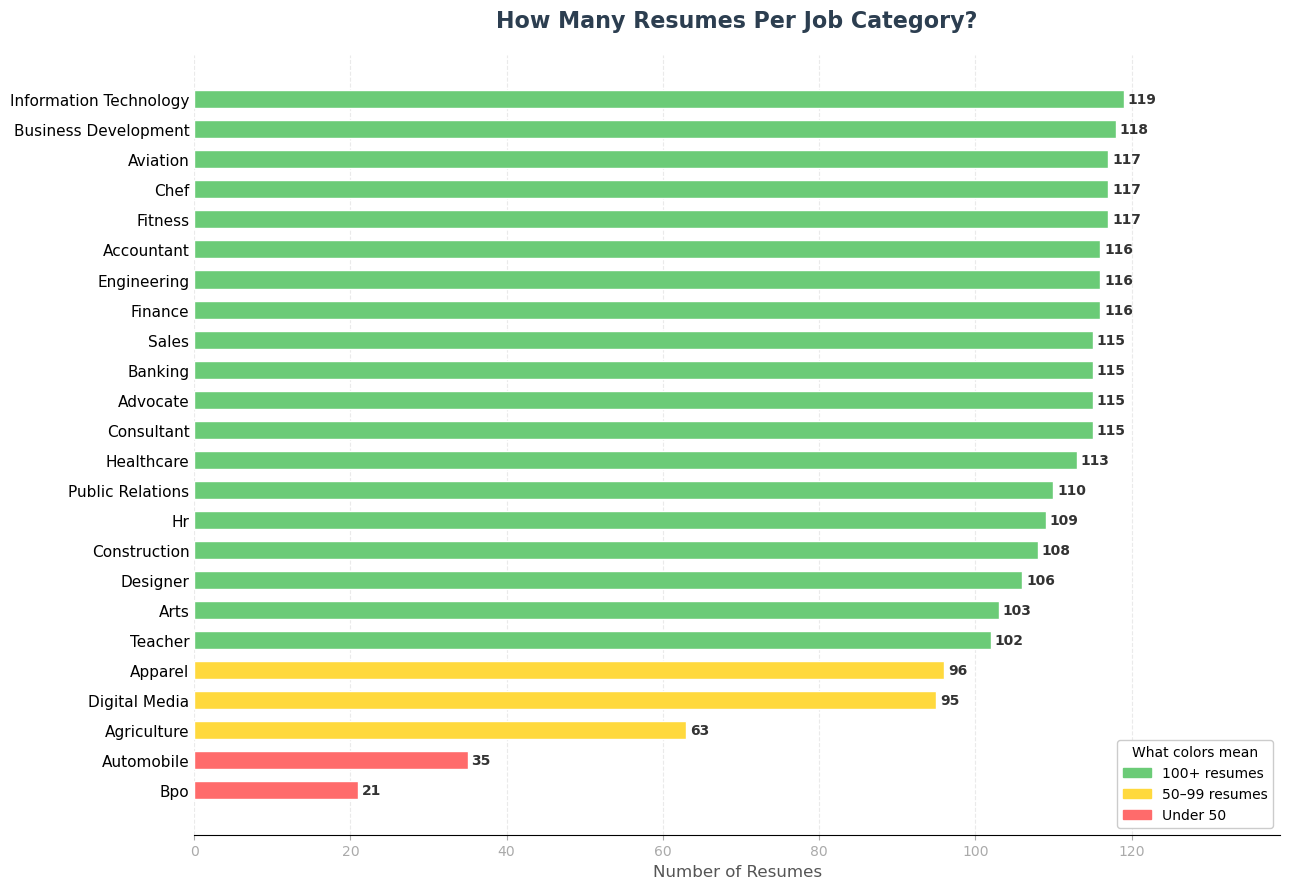

Chart 1 saved!


In [32]:
fig, ax = plt.subplots(figsize=(13, 9))

cat_counts = df['Cat_Clean'].value_counts(
    ).sort_values(ascending=True)

colors = ['#ff6b6b' if v < 50
          else '#ffd93d' if v < 100
          else '#6bcb77'
          for v in cat_counts.values]

bars = ax.barh(cat_counts.index,
               cat_counts.values,
               color=colors,
               edgecolor='white',
               height=0.6)

# Count at end of bar
for bar, val in zip(bars, cat_counts.values):
    ax.text(val + 0.5,
            bar.get_y() + bar.get_height()/2,
            str(val),
            va='center', ha='left',
            fontsize=10, fontweight='bold',
            color='#333333')

ax.set_xlim(0, cat_counts.max() + 20)
ax.set_xlabel('Number of Resumes',
              fontsize=12, color='#555555')
ax.set_title('How Many Resumes Per Job Category?',
             fontsize=16, fontweight='bold',
             color='#2c3e50', pad=20)

# Legend
p1 = mpatches.Patch(color='#6bcb77',
                     label='100+ resumes')
p2 = mpatches.Patch(color='#ffd93d',
                     label='50–99 resumes')
p3 = mpatches.Patch(color='#ff6b6b',
                     label='Under 50')
ax.legend(handles=[p1,p2,p3],
          fontsize=10, loc='lower right',
          framealpha=1.0,
          title='What colors mean',
          title_fontsize=10)

ax.xaxis.grid(True, linestyle='--',
              alpha=0.4, color='#cccccc')
ax.set_axisbelow(True)
ax.set_facecolor('#ffffff')
fig.patch.set_facecolor('#ffffff')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0,
               labelsize=11)
ax.tick_params(axis='x', colors='#aaaaaa')

plt.tight_layout()
plt.savefig('../notebooks/viz_01_category.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Chart 1 saved!")

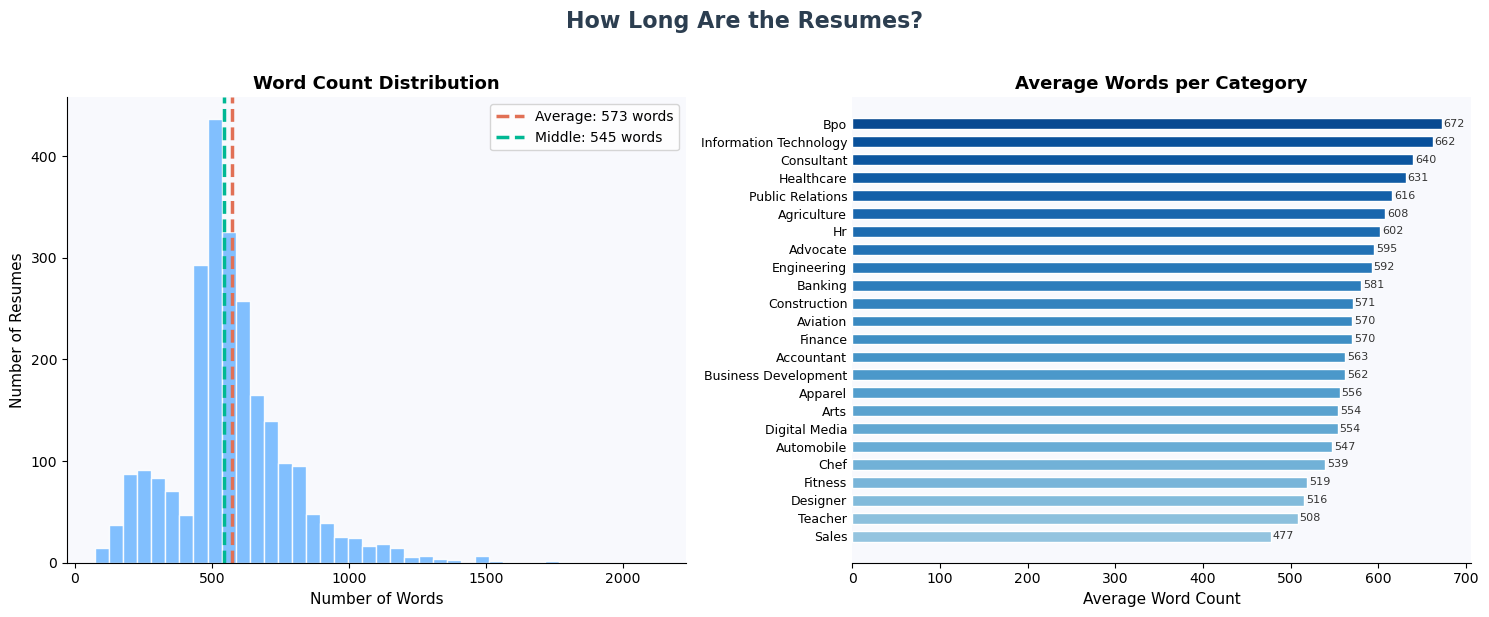

Chart 2 saved!


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('How Long Are the Resumes?',
             fontsize=16, fontweight='bold',
             color='#2c3e50', y=1.02)

# ── Left: Histogram ───────────────────────────────────────
axes[0].hist(df['Word_Count'],
             bins=40,
             color='#74b9ff',
             edgecolor='white',
             alpha=0.9)
axes[0].axvline(df['Word_Count'].mean(),
                color='#e17055',
                linewidth=2.5,
                linestyle='--',
                label=f"Average: "
                      f"{df['Word_Count'].mean():.0f} words")
axes[0].axvline(df['Word_Count'].median(),
                color='#00b894',
                linewidth=2.5,
                linestyle='--',
                label=f"Middle: "
                      f"{df['Word_Count'].median():.0f} words")
axes[0].set_title('Word Count Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words',
                   fontsize=11)
axes[0].set_ylabel('Number of Resumes',
                   fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_facecolor('#f8f9fd')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right: Average word count per category ────────────────
avg_words = df.groupby('Cat_Clean')['Word_Count'
    ].mean().sort_values(ascending=True)

colors2 = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(avg_words)))
axes[1].barh(avg_words.index,
             avg_words.values,
             color=colors2,
             edgecolor='white',
             height=0.6)

for i, val in enumerate(avg_words.values):
    axes[1].text(val + 2, i,
                 f'{val:.0f}',
                 va='center', fontsize=8,
                 color='#333333')

axes[1].set_title('Average Words per Category',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Word Count',
                   fontsize=11)
axes[1].set_facecolor('#f8f9fd')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].tick_params(axis='y', length=0,
                    labelsize=9)

plt.tight_layout()
plt.savefig('../notebooks/viz_02_wordcount.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Chart 2 saved!")

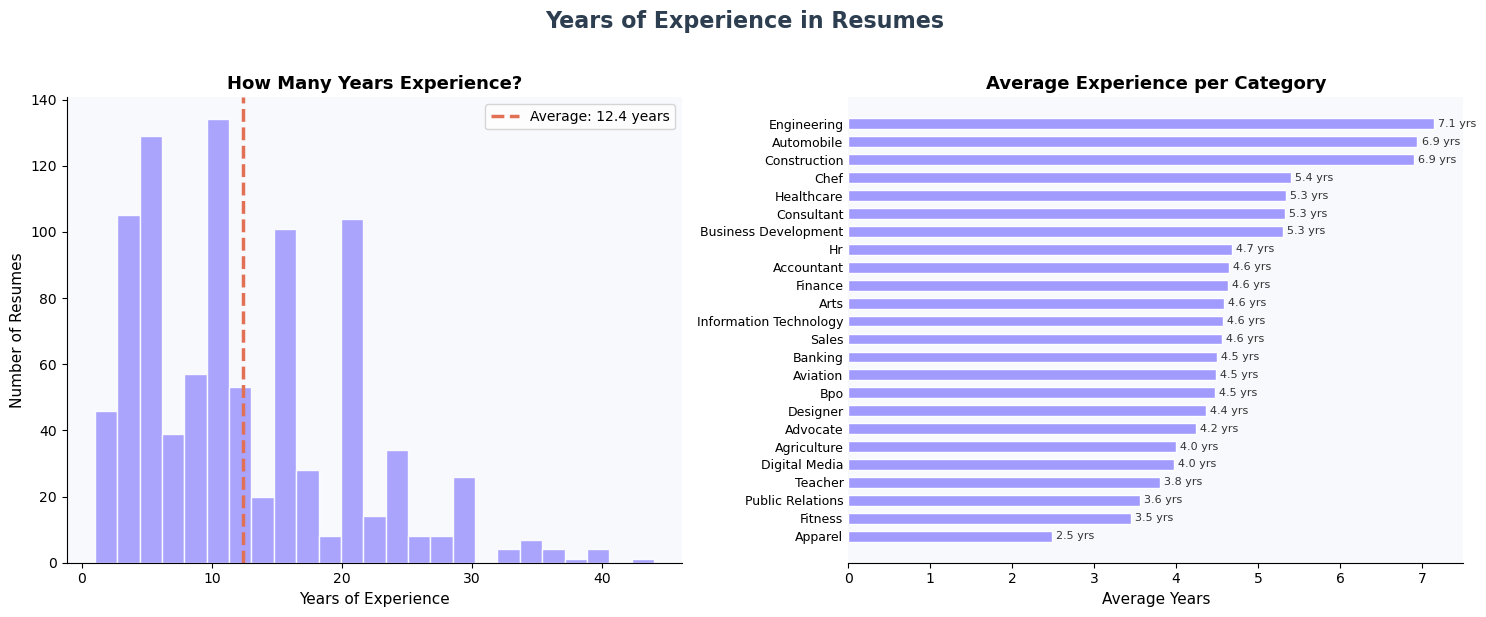

Chart 3 saved!


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Years of Experience in Resumes',
             fontsize=16, fontweight='bold',
             color='#2c3e50', y=1.02)

# ── Left: Histogram ───────────────────────────────────────
exp_data = df[df['Years_Exp'] > 0]['Years_Exp']
axes[0].hist(exp_data,
             bins=25,
             color='#a29bfe',
             edgecolor='white',
             alpha=0.9)
axes[0].axvline(exp_data.mean(),
                color='#e17055',
                linewidth=2.5,
                linestyle='--',
                label=f"Average: "
                      f"{exp_data.mean():.1f} years")
axes[0].set_title('How Many Years Experience?',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Years of Experience',
                   fontsize=11)
axes[0].set_ylabel('Number of Resumes',
                   fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_facecolor('#f8f9fd')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right: Avg experience per category ────────────────────
avg_exp = df.groupby('Cat_Clean')['Years_Exp'
    ].mean().sort_values(ascending=True)

colors3 = ['#a29bfe'] * len(avg_exp)
axes[1].barh(avg_exp.index,
             avg_exp.values,
             color=colors3,
             edgecolor='white',
             height=0.6)

for i, val in enumerate(avg_exp.values):
    axes[1].text(val + 0.05, i,
                 f'{val:.1f} yrs',
                 va='center', fontsize=8,
                 color='#333333')

axes[1].set_title('Average Experience per Category',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Years',
                   fontsize=11)
axes[1].set_facecolor('#f8f9fd')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].tick_params(axis='y', length=0,
                    labelsize=9)

plt.tight_layout()
plt.savefig('../notebooks/viz_03_experience.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Chart 3 saved!")

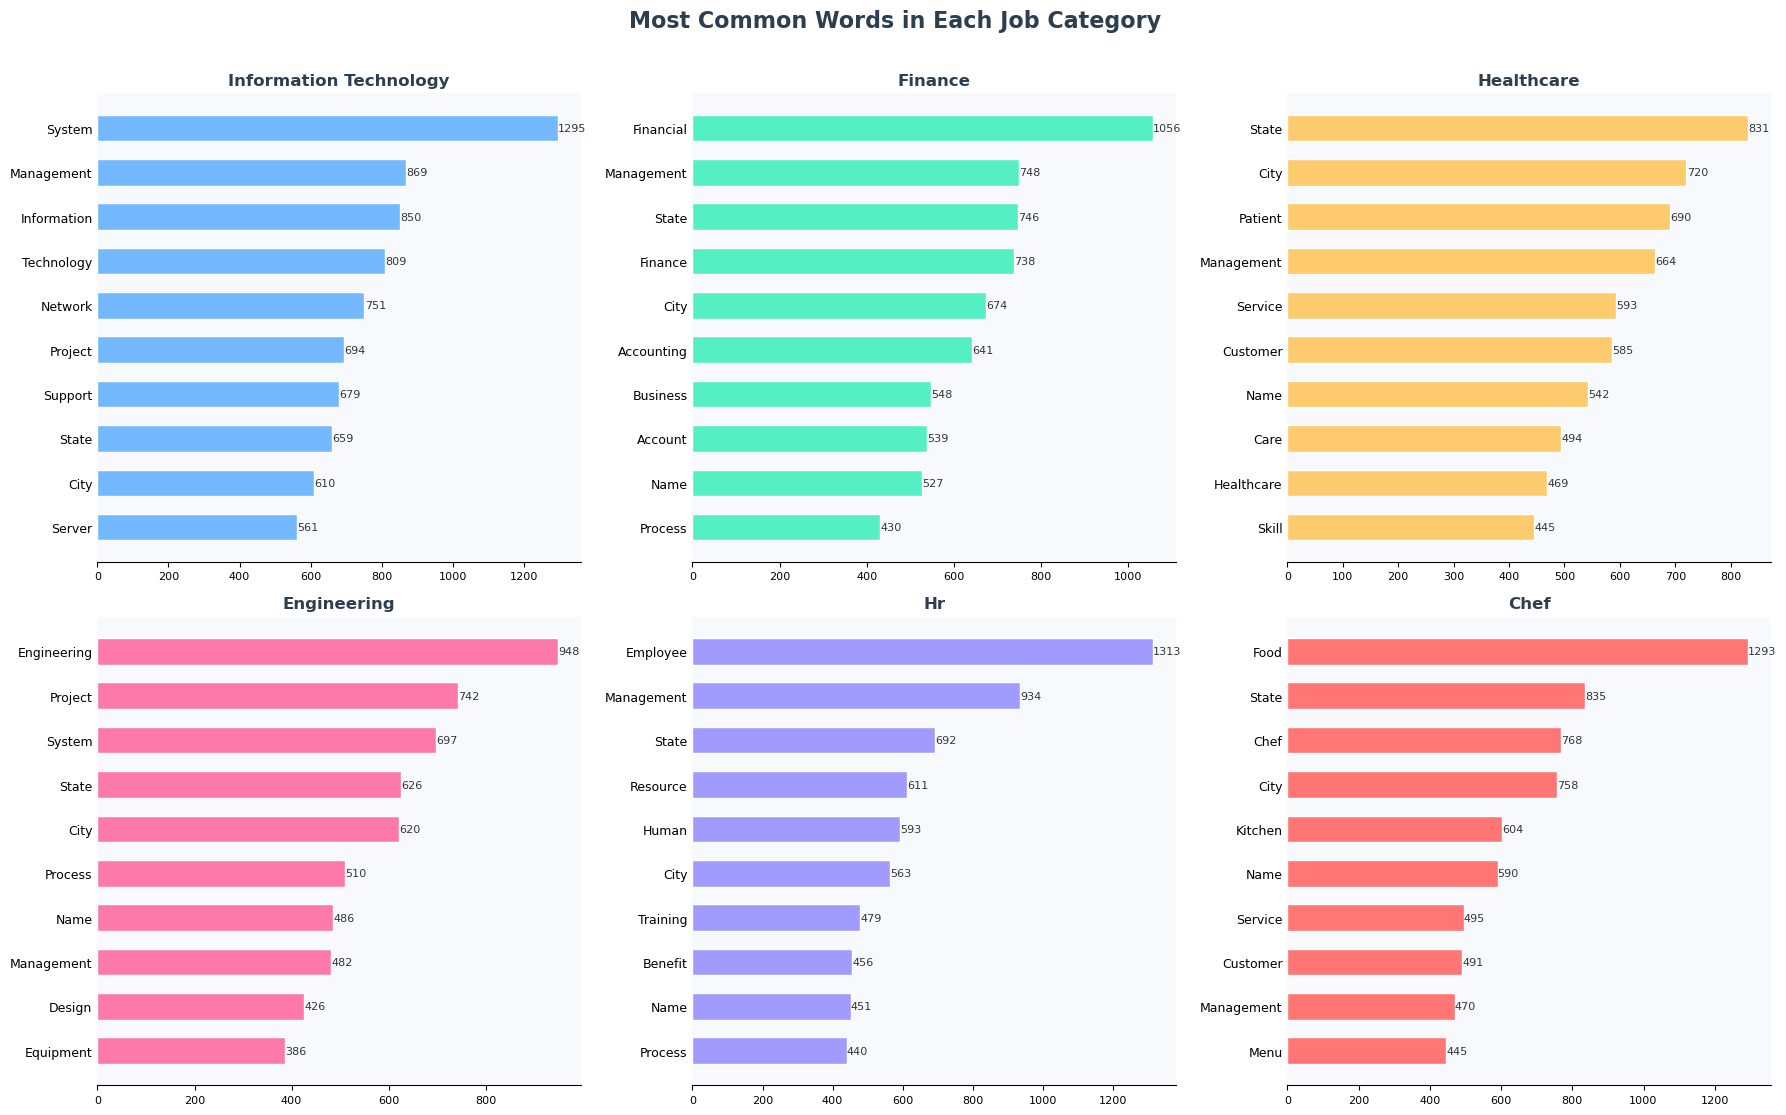

Chart 4 saved!


In [36]:
from collections import Counter

# Pick 6 interesting categories
selected = [
    'Information Technology',
    'Finance', 'Healthcare',
    'Engineering', 'Hr', 'Chef'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'Most Common Words in Each Job Category',
    fontsize=16, fontweight='bold',
    color='#2c3e50', y=1.01)

axes = axes.flatten()

# Words to ignore
ignore = {
    'the','and','to','of','in','a','for',
    'with','is','on','at','an','as','are',
    'was','be','has','have','this','that',
    'by','from','or','it','we','our','their',
    'will','all','been','more','also','such',
    'they','but','can','not','its','had',
    'were','who','one','which','when','would',
    'work', 'company', 'including', 'provide',
    'used', 'new', 'team', 'using', 'use',
}

colors_kw = ['#74b9ff','#55efc4',
             '#fdcb6e','#fd79a8',
             '#a29bfe','#ff7675']

for idx, cat in enumerate(selected):
    ax     = axes[idx]
    # Filter resumes for this category
    mask   = df['Cat_Clean'] == cat
    texts  = df[mask]['Clean_Resume'].str.lower()
    words  = ' '.join(texts).split()
    words  = [w for w in words
              if w not in ignore
              and len(w) > 3]
    # Top 10 words
    top10  = Counter(words).most_common(10)
    if not top10:
        continue
    labels = [w[0].title() for w in top10]
    counts = [w[1] for w in top10]

    bars = ax.barh(labels[::-1],
                   counts[::-1],
                   color=colors_kw[idx],
                   edgecolor='white',
                   height=0.6)

    for bar, val in zip(bars, counts[::-1]):
        ax.text(val + 0.5,
                bar.get_y() + bar.get_height()/2,
                str(val),
                va='center', fontsize=8,
                color='#333333')

    ax.set_title(cat,
                 fontsize=12,
                 fontweight='bold',
                 color='#2c3e50')
    ax.set_facecolor('#f8f9fd')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0,
                   labelsize=9)
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('../notebooks/viz_04_keywords.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Chart 4 saved!")

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, time, warnings, joblib
warnings.filterwarnings('ignore')

# NLP
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm                     import LinearSVC
from sklearn.calibration             import CalibratedClassifierCV
from sklearn.linear_model            import LogisticRegression
from sklearn.ensemble                import RandomForestClassifier
from sklearn.naive_bayes             import MultinomialNB
from sklearn.preprocessing           import LabelEncoder
from sklearn.model_selection         import (train_test_split,
                                             cross_val_score)
from sklearn.metrics                 import (accuracy_score,
                                             classification_report,
                                             confusion_matrix)
from sklearn.pipeline                import Pipeline
from sklearn.metrics.pairwise        import cosine_similarity
from imblearn.over_sampling          import SMOTE

# Load data
df = pd.read_csv(
    '../data/processed/resumes_final.csv',
    encoding='utf-8')
df['Clean_Resume'] = df['Clean_Resume'].fillna('')
df['Category']     = df['Category'].fillna('')
df = df[df['Clean_Resume'].str.len() > 10]
df.reset_index(drop=True, inplace=True)

print("All libraries loaded!")
print(f"Dataset: {len(df)} resumes | "
      f"{df['Category'].nunique()} categories")

All libraries loaded!
Dataset: 2457 resumes | 24 categories


In [39]:
!python -m spacy download en_core_web_md

     ---------------------------------------- 0.0/33.5 MB ? eta -:--:--
     ---------------------------------------- 0.0/33.5 MB ? eta -:--:--
      --------------------------------------- 0.5/33.5 MB 1.6 MB/s eta 0:00:21
      --------------------------------------- 0.8/33.5 MB 1.7 MB/s eta 0:00:20
     - -------------------------------------- 1.0/33.5 MB 1.7 MB/s eta 0:00:20
     - -------------------------------------- 1.6/33.5 MB 1.6 MB/s eta 0:00:20
     -- ------------------------------------- 1.8/33.5 MB 1.6 MB/s eta 0:00:20
     -- ------------------------------------- 2.4/33.5 MB 1.7 MB/s eta 0:00:18
     --- ------------------------------------ 2.6/33.5 MB 1.7 MB/s eta 0:00:19
     --- ------------------------------------ 2.9/33.5 MB 1.7 MB/s eta 0:00:18
     ---- ----------------------------------- 3.4/33.5 MB 1.7 MB/s eta 0:00:18
     ---- ----------------------------------- 3.7/33.5 MB 1.6 MB/s eta 0:00:19
     ---- ----------------------------------- 3.9/33.5 MB 1.6 MB/s

In [42]:
print("Loading spaCy model...")
nlp = spacy.load('en_core_web_md')
print("spaCy loaded!")

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

KEEP_WORDS = {
    'python','java','sql','excel','aws','gcp',
    'azure','machine','learning','deep','nlp',
    'tensorflow','pytorch','keras','flask',
    'django','docker','kubernetes','git',
    'management','leadership','communication',
    'analysis','finance','accounting','sales',
    'marketing','hr','recruitment','healthcare',
    'engineering','design','teaching','legal',
    'experience','years','project','team','lead',
}

def spacy_clean(text):
    """
    Enhanced NLP cleaning using spaCy + NLTK:
    1. Remove special characters
    2. spaCy lemmatization
    3. Keep only meaningful word types
    4. Remove stopwords (keep skill words)
    """
    text = str(text)
    text = re.sub(r'[^a-zA-Z\s]',' ',text)
    text = re.sub(r'\s+', ' ', text).strip().lower()

    # spaCy processing
    doc    = nlp(text[:50000])
    tokens = []
    for token in doc:
        word = token.lemma_.lower()
        if word in KEEP_WORDS:
            tokens.append(word)
        elif (word not in STOP_WORDS
              and len(word) > 2
              and token.pos_ in ('NOUN','VERB',
                                  'ADJ','PROPN')):
            tokens.append(word)
    return ' '.join(tokens)


sample = df['Clean_Resume'].iloc[1]
print()
print("Original (100 chars):")
print(sample[:100])
print()
print("spaCy cleaned (100 chars):")
print(spacy_clean(sample)[:100])
print()
print("spaCy cleaning function ready!")

Loading spaCy model...
spaCy loaded!

Original (100 chars):
specialist operation summary versatile medium professional background communication marketing human 

spaCy cleaned (100 chars):
specialist operation summary versatile medium professional background communication market human res

spaCy cleaning function ready!


In [43]:
print("Applying spaCy NLP to all resumes:")
print(" please wait...")
print()

start = time.time()
df['NLP_Resume'] = df['Clean_Resume'].apply(
    spacy_clean)

# Remove empty results
df['NLP_Resume'] = df['NLP_Resume'].fillna('')
df = df[df['NLP_Resume'].str.len() > 10]
df.reset_index(drop=True, inplace=True)

elapsed = time.time() - start
print("=" * 50)
print("spaCy CLEANING DONE!")
print("=" * 50)
print(f"Time        : {elapsed:.1f} seconds")
print(f"Resumes     : {len(df)}")
print()
print("Sample NLP result:")
print(df['NLP_Resume'].iloc[0][:200])

df.to_csv(
    '../data/processed/resumes_nlp.csv',
    index=False, encoding='utf-8')
print()
print("Saved: data/processed/resumes_nlp.csv")

Applying spaCy NLP to all resumes:
 please wait...

spaCy CLEANING DONE!
Time        : 601.7 seconds
Resumes     : 2457

Sample NLP result:
administrator marketing associate administrator summary dedicate customer service manager year experience hospitality customer service management respect builder leader customer focus team strive inst

Saved: data/processed/resumes_nlp.csv


In [44]:

X  = df['NLP_Resume'].values
le = LabelEncoder()
y  = le.fit_transform(df['Category'].values)

print("LABEL ENCODING")
print("=" * 50)
for i, cls in enumerate(le.classes_):
    count = (df['Category'] == cls).sum()
    bar   = '|' * (count // 8)
    print(f"  {i:2d}  {cls:<32}"
          f"{count:4d}  {bar}")

print()
print(f"Total classes : {len(le.classes_)}")
print(f"Total samples : {len(X)}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y)

print()
print(f"Train : {len(X_train)} (80%)")
print(f"Test  : {len(X_test)} (20%)")
print()
print("Data ready!")

LABEL ENCODING
   0  ACCOUNTANT                       116  ||||||||||||||
   1  ADVOCATE                         115  ||||||||||||||
   2  AGRICULTURE                       63  |||||||
   3  APPAREL                           96  ||||||||||||
   4  ARTS                             103  ||||||||||||
   5  AUTOMOBILE                        35  ||||
   6  AVIATION                         117  ||||||||||||||
   7  BANKING                          115  ||||||||||||||
   8  BPO                               21  ||
   9  BUSINESS-DEVELOPMENT             118  ||||||||||||||
  10  CHEF                             117  ||||||||||||||
  11  CONSTRUCTION                     108  |||||||||||||
  12  CONSULTANT                       115  ||||||||||||||
  13  DESIGNER                         106  |||||||||||||
  14  DIGITAL-MEDIA                     95  |||||||||||
  15  ENGINEERING                      116  ||||||||||||||
  16  FINANCE                          116  ||||||||||||||
  17  FITNESS       

In [45]:
print("Building TF-IDF matrix...")

tfidf = TfidfVectorizer(
    max_features  = 8000,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    strip_accents = 'unicode',
    analyzer      = 'word',
    min_df        = 2,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("=" * 50)
print(" TF-IDF DONE!")
print("=" * 50)
print(f"Train matrix : {X_train_tfidf.shape}")
print(f"Test matrix  : {X_test_tfidf.shape}")
print(f"Vocabulary   : {len(tfidf.vocabulary_)}")
print()

names = tfidf.get_feature_names_out()
sums  = X_train_tfidf.sum(axis=0).A1
top20 = sums.argsort()[::-1][:20]
print("Top 20 important words:")
print([names[i] for i in top20])

Building TF-IDF matrix...
 TF-IDF DONE!
Train matrix : (1965, 8000)
Test matrix  : (492, 8000)
Vocabulary   : 8000

Top 20 important words:
['state', 'city', 'company', 'city state', 'name', 'company name', 'name city', 'management', 'customer', 'service', 'sale', 'work', 'skill', 'business', 'client', 'team', 'manage', 'project', 'new', 'system']


In [46]:
print("Fixing class imbalance:")
print("BPO=21, Automobile=35 — too small!")
print()

smote = SMOTE(random_state=42, k_neighbors=2)
X_bal, y_bal = smote.fit_resample(
    X_train_tfidf, y_train)

print("=" * 50)
print("SMOTE DONE!")
print("=" * 50)
print(f"Before : {X_train_tfidf.shape[0]}")
print(f"After  : {X_bal.shape[0]}")
print()

from collections import Counter
counts = Counter(y_bal)
print("Samples per class after SMOTE:")
for idx in sorted(counts.keys()):
    cat = le.inverse_transform([idx])[0]
    bar = '|' * (counts[idx] // 15)
    print(f"  {cat:<32}"
          f"{counts[idx]:4d}  {bar}")

Fixing class imbalance:
BPO=21, Automobile=35 — too small!

SMOTE DONE!
Before : 1965
After  : 2280

Samples per class after SMOTE:
  ACCOUNTANT                        95  ||||||
  ADVOCATE                          95  ||||||
  AGRICULTURE                       95  ||||||
  APPAREL                           95  ||||||
  ARTS                              95  ||||||
  AUTOMOBILE                        95  ||||||
  AVIATION                          95  ||||||
  BANKING                           95  ||||||
  BPO                               95  ||||||
  BUSINESS-DEVELOPMENT              95  ||||||
  CHEF                              95  ||||||
  CONSTRUCTION                      95  ||||||
  CONSULTANT                        95  ||||||
  DESIGNER                          95  ||||||
  DIGITAL-MEDIA                     95  ||||||
  ENGINEERING                       95  ||||||
  FINANCE                           95  ||||||
  FITNESS                           95  ||||||
  HEALTHCARE          

In [47]:
print("Training all 4 models:")
print("=" * 50)

results        = {}
trained_models = {}
predictions    = {}

 # SVM 
print("\n1/4  SVM :")
t   = time.time()
svm = CalibratedClassifierCV(
    LinearSVC(
        class_weight = 'balanced',
        max_iter     = 3000,
        C            = 1.0), cv=3)
svm.fit(X_bal, y_bal)
svm_pred              = svm.predict(X_test_tfidf)
svm_acc               = accuracy_score(
                            y_test, svm_pred)
results['SVM']        = svm_acc
trained_models['SVM'] = svm
predictions['SVM']    = svm_pred
print(f" {svm_acc*100:.2f}%  "
      f"({time.time()-t:.1f}s)")

# 2. Logistic Regression 
print("\n2/4  Logistic Regression...")
t  = time.time()
lr = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    C            = 1.5,
    solver       = 'saga',
    multi_class  = 'multinomial',
    n_jobs       = -1)
lr.fit(X_bal, y_bal)
lr_pred                          = lr.predict(
                                       X_test_tfidf)
lr_acc                           = accuracy_score(
                                       y_test, lr_pred)
results['Logistic Regression']   = lr_acc
trained_models['Logistic Regression'] = lr
predictions['Logistic Regression']    = lr_pred
print(f"    {lr_acc*100:.2f}%  "
      f"({time.time()-t:.1f}s)")

# 3. Random Forest
print("\n3/4  Random Forest...")
t  = time.time()
rf = RandomForestClassifier(
    n_estimators = 300,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1)
rf.fit(X_bal, y_bal)
rf_pred                    = rf.predict(X_test_tfidf)
rf_acc                     = accuracy_score(
                                 y_test, rf_pred)
results['Random Forest']   = rf_acc
trained_models['Random Forest'] = rf
predictions['Random Forest']    = rf_pred
print(f" {rf_acc*100:.2f}%  "
      f"({time.time()-t:.1f}s)")

#  4. Naive Bayes 
print("\n4/4  Naive Bayes...")
t  = time.time()
nb = MultinomialNB(alpha=0.1)
nb.fit(X_bal, y_bal)
nb_pred                  = nb.predict(X_test_tfidf)
nb_acc                   = accuracy_score(
                               y_test, nb_pred)
results['Naive Bayes']   = nb_acc
trained_models['Naive Bayes'] = nb
predictions['Naive Bayes']    = nb_pred
print(f"   {nb_acc*100:.2f}%  "
      f"({time.time()-t:.1f}s)")


print()
print("=" * 50)
print("FINAL RESULTS")
print("=" * 50)
best_name = max(results, key=results.get)
for name, acc in sorted(
        results.items(),
        key=lambda x: x[1],
        reverse=True):
    medal = "1." if name == best_name else "  "
    bar   = '|' * int(acc * 50)
    print(f"{medal} {name:<25}"
          f"{acc*100:.2f}%  {bar}")
print()
print(f" Best: {best_name} "
      f"({results[best_name]*100:.2f}%)")

Training all 4 models:

1/4  SVM :
 73.17%  (2.6s)

2/4  Logistic Regression...
    68.50%  (2.8s)

3/4  Random Forest...
 75.00%  (3.9s)

4/4  Naive Bayes...
   59.35%  (0.0s)

FINAL RESULTS
1. Random Forest            75.00%  |||||||||||||||||||||||||||||||||||||
   SVM                      73.17%  ||||||||||||||||||||||||||||||||||||
   Logistic Regression      68.50%  ||||||||||||||||||||||||||||||||||
   Naive Bayes              59.35%  |||||||||||||||||||||||||||||

 Best: Random Forest (75.00%)


In [48]:
best_pred = predictions[best_name]

print(f"DETAILED REPORT — {best_name}")
print("=" * 60)
print(classification_report(
    y_test, best_pred,
    target_names  = le.classes_,
    zero_division = 0))

DETAILED REPORT — Random Forest
                        precision    recall  f1-score   support

            ACCOUNTANT       0.65      0.96      0.77        23
              ADVOCATE       0.79      0.65      0.71        23
           AGRICULTURE       1.00      0.54      0.70        13
               APPAREL       0.71      0.53      0.61        19
                  ARTS       0.80      0.19      0.31        21
            AUTOMOBILE       0.33      0.14      0.20         7
              AVIATION       0.88      0.88      0.88        24
               BANKING       0.68      0.65      0.67        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.77      0.83      0.80        24
                  CHEF       0.86      0.78      0.82        23
          CONSTRUCTION       0.88      0.95      0.91        22
            CONSULTANT       0.82      0.61      0.70        23
              DESIGNER       0.90      0.86      0.88        21
       

In [49]:
print("Building final pipeline:")

final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features  = 8000,
        ngram_range   = (1, 2),
        sublinear_tf  = True,
        strip_accents = 'unicode',
        min_df        = 2,
    )),
    ('clf', CalibratedClassifierCV(
        LinearSVC(
            class_weight = 'balanced',
            max_iter     = 3000,
            C            = 1.0
        ), cv=3))
])

print("Training on full dataset:")
final_pipeline.fit(X, y)

os.makedirs('../models', exist_ok=True)
joblib.dump(final_pipeline,
    '../models/resume_classifier.pkl')
joblib.dump(le,
    '../models/label_encoder.pkl')
joblib.dump(tfidf,
    '../models/tfidf_vectorizer.pkl')

print("=" * 50)
print("MODELS SAVED!")
print("=" * 50)
print("  models/resume_classifier.pkl")
print("  models/label_encoder.pkl")
print("  models/tfidf_vectorizer.pkl")

Building final pipeline:
Training on full dataset:
MODELS SAVED!
  models/resume_classifier.pkl
  models/label_encoder.pkl
  models/tfidf_vectorizer.pkl


In [50]:
def predict_resume(text):
    model   = joblib.load(
        '../models/resume_classifier.pkl')
    encoder = joblib.load(
        '../models/label_encoder.pkl')
    text    = str(text)
    text    = re.sub(
        r'[^a-zA-Z\s]',' ',text).lower()
    pred    = model.predict([text])[0]
    proba   = model.predict_proba([text])[0]
    cat     = encoder.inverse_transform([pred])[0]
    conf    = round(proba.max()*100, 1)
    top3    = [(encoder.inverse_transform([i])[0],
                round(proba[i]*100,1))
               for i in proba.argsort()[::-1][:3]]
    return cat, conf, top3

print("TESTING PREDICTIONS")
print("=" * 55)
test_cats = ['INFORMATION-TECHNOLOGY',
             'HR','FINANCE',
             'ENGINEERING','CHEF']
correct   = 0
for cat in test_cats:
    sample = df[df['Category']==cat
               ]['NLP_Resume'].iloc[0]
    pred, conf, top3 = predict_resume(sample)
    ok = "yes" if pred == cat else "no"
    if pred == cat:
        correct += 1
    print(f"{ok} True     : {cat}")
    print(f"   Predicted : {pred} ({conf}%)")
    print(f"   Top 3     : {top3}")
    print()
print(f"Score: {correct}/{len(test_cats)}")

TESTING PREDICTIONS
yes True     : INFORMATION-TECHNOLOGY
   Predicted : INFORMATION-TECHNOLOGY (82.3%)
   Top 3     : [('INFORMATION-TECHNOLOGY', np.float64(82.3)), ('ENGINEERING', np.float64(2.1)), ('CONSULTANT', np.float64(2.0))]

yes True     : HR
   Predicted : HR (66.7%)
   Top 3     : [('HR', np.float64(66.7)), ('PUBLIC-RELATIONS', np.float64(6.1)), ('HEALTHCARE', np.float64(4.4))]

yes True     : FINANCE
   Predicted : FINANCE (81.9%)
   Top 3     : [('FINANCE', np.float64(81.9)), ('SALES', np.float64(2.0)), ('APPAREL', np.float64(1.9))]

yes True     : ENGINEERING
   Predicted : ENGINEERING (77.6%)
   Top 3     : [('ENGINEERING', np.float64(77.6)), ('CONSULTANT', np.float64(6.7)), ('APPAREL', np.float64(2.4))]

yes True     : CHEF
   Predicted : CHEF (75.5%)
   Top 3     : [('CHEF', np.float64(75.5)), ('HEALTHCARE', np.float64(8.9)), ('ADVOCATE', np.float64(2.7))]

Score: 5/5


In [51]:
def rank_candidates(job_desc, dataframe,
                    top_n=10):
    """Rank all resumes against a job description."""
    clean_jd  = re.sub(
        r'[^a-zA-Z\s]',' ',
        job_desc).lower()
    all_texts = ([clean_jd] +
                 dataframe['NLP_Resume'].tolist())
    vec = TfidfVectorizer(
        sublinear_tf=True, min_df=1)
    mat = vec.fit_transform(all_texts)
    scores = cosine_similarity(
        mat[0:1], mat[1:]).flatten()
    result            = dataframe.copy()
    result['Score %'] = (scores*100).round(2)
    top = result.nlargest(top_n,'Score %')
    top = top.reset_index(drop=True)
    top.index = top.index + 1
    top.index.name = 'Rank'
    return top[['Category',
                'Score %',
                'Years_Exp',
                'Email']]

# Test ranking
my_jd = """
Looking for Senior Python Developer
with 3+ years experience in machine
learning, SQL, AWS and data analysis.
"""
print("TOP 10 CANDIDATES")
print("=" * 50)
top10 = rank_candidates(my_jd, df, top_n=10)
print(top10.to_string())

TOP 10 CANDIDATES
                    Category  Score %  Years_Exp Email
Rank                                                  
1                 CONSULTANT     8.26          6   NaN
2              DIGITAL-MEDIA     7.96          0   NaN
3                AGRICULTURE     7.76         20   NaN
4                ENGINEERING     7.54          3   NaN
5                    BANKING     6.81          0   NaN
6                ENGINEERING     6.62          0   NaN
7     INFORMATION-TECHNOLOGY     6.55         13   NaN
8                ENGINEERING     6.54         17   NaN
9                      SALES     6.24          0   NaN
10               AGRICULTURE     5.98          5   NaN


In [52]:
# Make sure balancing was applied correctly
print("Training class distribution:")
from collections import Counter
print(Counter(y_train))  
# All classes should show equal or near-equal counts

Training class distribution:
Counter({np.int64(20): 95, np.int64(17): 94, np.int64(10): 94, np.int64(9): 94, np.int64(16): 93, np.int64(6): 93, np.int64(0): 93, np.int64(15): 93, np.int64(7): 92, np.int64(12): 92, np.int64(1): 92, np.int64(22): 92, np.int64(18): 90, np.int64(21): 88, np.int64(19): 87, np.int64(11): 86, np.int64(13): 85, np.int64(4): 82, np.int64(23): 82, np.int64(3): 77, np.int64(14): 76, np.int64(2): 50, np.int64(5): 28, np.int64(8): 17})
